In [8]:
import matplotlib.cm as cm
import numpy as np 
import matplotlib.pyplot as plt 
import os
from utils import load_json_safely
from analysis_scripts import get_interpolation_EIS
#from utils import extract_parameters
######################
######################/Volumes/Raw_lab_data/B310/323-Electrochemistry/3413-Catbot-3425/EC_data_CatBot/Ni_Mo_optimization_Thu_Jonas/Investigating_Ni_Mo_degradation
json_paths = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Individual_data/Ni_Mo_degradation"
ECSA_json_path = os.path.join(json_paths, "ECSA.json")
Stability_json_path = os.path.join(json_paths, "Stability_anodic.json")
EIS_json_path = os.path.join(json_paths, "EIS.json")

save_pic_path = "/Users/pvifr/Desktop/ElectrochemicalDataAnalysis/Ni_Mo_paper/Figures/Reproducibility"
# Loading data
ecsa_data = load_json_safely(ECSA_json_path)
stability_data = load_json_safely(Stability_json_path)
eis_data = load_json_safely(EIS_json_path)


# Reproducibility 1 M 

In [9]:
# Get the datasets 
from utils import extract_subprotocols_with_idxs, extract_subprotocol_data
from analysis_scripts import transform_EIS_data_to_dict, transform_CVs_to_stability_metrics, transform_CVs_to_ECSA
import numpy as np 
import json 
from datetime import datetime
folder = "/Volumes/ENRGK/Raw_lab_data/B313/307-Automated Synthesis/3413-Catbot-3425/EC_data_CatBot/NiMo optimizations all/Ni_Mo_Optimization_Jonas/Reproducibility_coatings_1M_69M_KOH"

def get_IR_correction(Re_Z, Im_Z, X_MIN = 0.6, X_MAX = 1.0):
        
    Y_MIN, Y_MAX = -0.1, 0.1     # -Im(Z) window

    mask = (
            (Re_Z >= X_MIN) & (Re_Z <= X_MAX) &
            (Im_Z >= Y_MIN) & (Im_Z <= Y_MAX)
        )
    
    x = Re_Z[mask]
    y = Im_Z[mask]
    print(x, y)
    sign_change = np.where(np.diff(np.sign(y)))[0]
    idx = sign_change[0]

    # linear interpolation
    x1, x2 = x[idx], x[idx+1]
    y1, y2 = y[idx], y[idx+1]

    x_cross = x1 - y1 * (x2 - x1) / (y2 - y1)

    return x_cross




In [6]:
import os
import json
import pandas as pd
import time 
import matplotlib.pyplot as plt 
# Dictionary to group experiments by deposition time
groups_1M = {}  # format: {dep_time: [list of experiments' data dicts]}
groups_69M = {}

for subfolder in os.listdir(folder):
    try:
        if "_exp" not in subfolder:
            continue

        folderpath = os.path.join(folder, subfolder)
        parameter_dict_path = None
        df_data_path = None
        CV_calibration_file = None
        
        # Locate files
        for file in os.listdir(folderpath):
            if "parameter" in file and file.endswith(".json"):
                parameter_dict_path = os.path.join(folderpath, file)
            elif "Testing_data" in file and file.endswith(".csv"):
                df_data_path = os.path.join(folderpath, file)
            elif "calibration" in file and file.endswith(".csv"):
                CV_calibration_file = os.path.join(folderpath, file)

        if parameter_dict_path is None or df_data_path is None:
            continue  # skip if essential files are missing

        # Load parameter dict
        with open(parameter_dict_path, "r") as f:
            parameter_dict = json.load(f)

        exp_name = [key for key in parameter_dict if key.endswith(".csv")][0]
        dep_time = parameter_dict[exp_name]["Deposition time [s]"]
        timestamp_str = parameter_dict["timestamp"]
        testing_conc = parameter_dict[exp_name]["Stock solutions"]["Pump 1"]["Contents"]["KOH"]["Concentration [mol/L]"]
        # Read experimental data
        df = pd.read_csv(df_data_path)
        subprotocol_idxs = extract_subprotocols_with_idxs(parameter_dict_path)

        # Extract subprotocols
        data_stability_scans = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Stability scans NiMo"
        )

        data_ECSA_before = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="ECSA scans NiMo before cycling"
        )

        data_ECSA_after = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="ECSA scans NiMo after cycling"
        )

        ECSA_dict_before_after = transform_CVs_to_ECSA(
            [data_ECSA_before, data_ECSA_after],
            names=["Cap current init [mA]", "Cap current final [mA]"],
            plot_CVs=False
        )

        data_GEIS_initial = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Initial GEIS",
            selected_protocol="GEIS"
        )

        data_GEIS_final = extract_subprotocol_data(
            df=df,
            subprotocol_idxs=subprotocol_idxs,
            selected_comment="Final GEIS",
            selected_protocol="GEIS"
        )

        EIS_dict = transform_EIS_data_to_dict(
            EIS_measurements=[data_GEIS_initial, data_GEIS_final],
            names=["GEIS initial", "GEIS final"],
            plot_EIS=False
        )
        
        IR_correction = EIS_dict["GEIS initial"]["IR correction"]
        print(IR_correction)

        if IR_correction == 0:
            if float(testing_conc) > 1:

                IR_correction = get_IR_correction(Re_Z=np.array(EIS_dict["GEIS initial"]["Re_Z"]), 
                                                    Im_Z=np.array(EIS_dict["GEIS initial"]["Im_Z"]), 
                                                    X_MIN=0.4, X_MAX=0.6)
            else:
                IR_correction = get_IR_correction(Re_Z=np.array(EIS_dict["GEIS initial"]["Re_Z"]), 
                                                    Im_Z=np.array(EIS_dict["GEIS initial"]["Im_Z"]))
        
        Stability_dict = transform_CVs_to_stability_metrics(
            stability_cycling_CVs=data_stability_scans,
            current_densities=[1, 10, 100],
            IR_correction=IR_correction
        )

        # ----------------------------
        # Group by deposition time
        # ----------------------------
        exp_data = {
            "subfolder": subfolder,
            "ECSA": ECSA_dict_before_after,
            "EIS": EIS_dict,
            "Stability": Stability_dict,
            "parameter_dict": parameter_dict,
        }   

        dt = datetime.strptime(timestamp_str, "%d.%m.%Y at %H:%M")
        march_1 = datetime(2026, 3, 1)
        
        if float(testing_conc) > 1:
            if dep_time not in groups_69M:
                groups_69M[dep_time] = []
            groups_69M[dep_time].append(exp_data)
        elif dt > march_1:
            if dep_time not in groups_69M:
                groups_69M[dep_time] = []
            groups_69M[dep_time].append(exp_data)
        else:
            if dep_time not in groups_1M:
                groups_1M[dep_time] = []
            groups_1M[dep_time].append(exp_data)
        
    
    except Exception as e:
        print(f"Skipped {subfolder}: {e}")
        
        continue

# ----------------------------
# Now `groups` contains all experiments grouped by deposition time
# Example: loop through groups and plot ECSA
# ----------------------------
for dep_time, exps in groups.items():
    print(f"\nDeposition time: {dep_time} s, Number of experiments: {len(exps)}")

    # Example: plot ECSA before and after for all experiments in this group
    for exp in exps:
        ECSA_dict = exp["ECSA"]
        # ECSA_dict structure: {"scan_rate": {"Cap current init [mA]": [...], "Cap current final [mA]": [...]}}
        # You can implement plotting logic here

0.58
0.76
0.47
0.46
0.82
0.55
0.71
0.61
0.73
0.91
0.56
0.57
0.52
0.81
0.79
0.71
0.79
0.57
0.58
0.67
0.65
0.55
0.82
0.45


NameError: name 'groups' is not defined

# Stability cycling

['533.5', '405.5', '148.6']
533.5


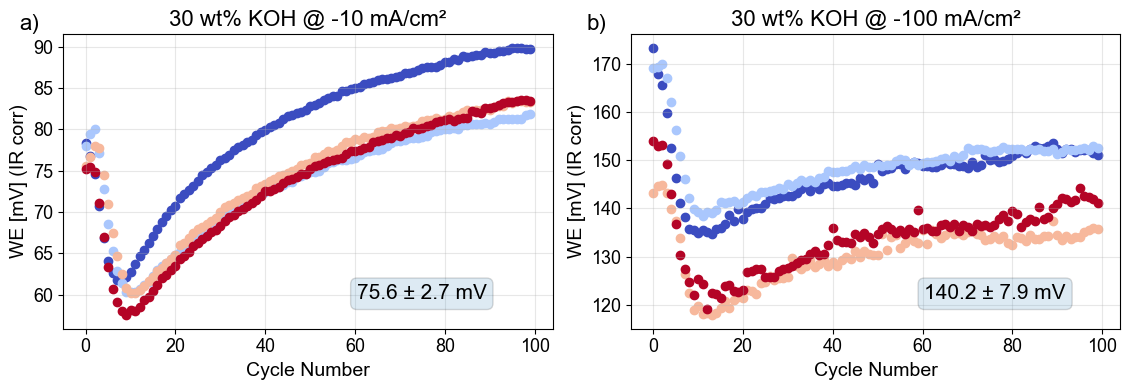

405.5


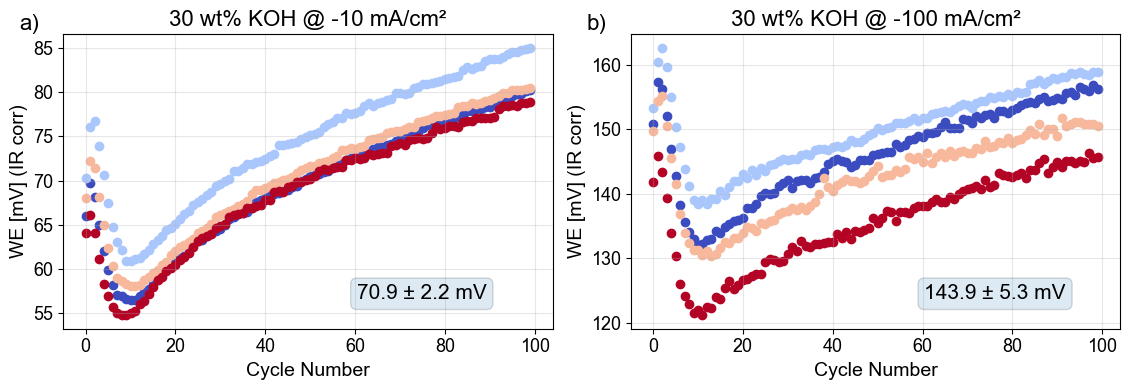

148.6


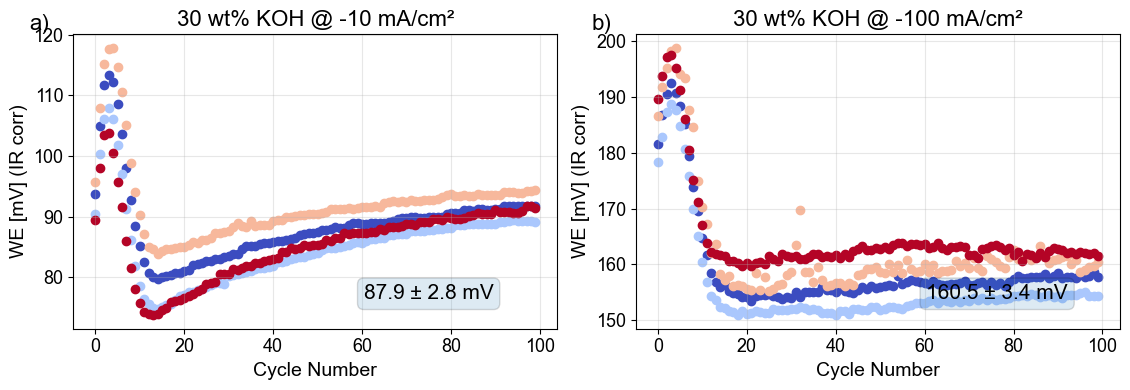

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

# -------- SETTINGS --------
plot_mode = "6.9M"   # options: "6.9M" or "both"

# 1. Globally set the font to Arial / Sans-Serif
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# 2. Make sure LaTeX elements (like \langle and \eta) also match the sans-serif style
plt.rcParams['mathtext.fontset'] = 'dejavusans'  # Sans-serif math font style

dep_times = list(groups_69M.keys())
current_densities_list = [10, 100]
targets = ['Overpotentials at 10 mA/cm2', 'Overpotentials at 100 mA/cm2']

savepath_reproducibility = "/Users/pvifr/Desktop/PhD_general/Ni_Mo_paper/First review/Revised graphs"

print(dep_times)

# -------- LOOP OVER DEPOSITION TIMES --------
for dep_time in dep_times:

    # ----- CREATE FIGURE -----
    if plot_mode == "both":
        fig, axes = plt.subplots(len(targets), 2, figsize=(12, 8), sharey='row')
    else:  # only 6.9M → side-by-side
        fig, axes = plt.subplots(1, len(targets), figsize=(12, 4), sharey=False)

    print(dep_time)

    exps_69M = groups_69M[dep_time]
    exps_1M = groups_1M[dep_time] if plot_mode == "both" else []

    n_exps = max(len(exps_69M), len(exps_1M)) if plot_mode == "both" else len(exps_69M)
    cmap = plt.cm.coolwarm(np.linspace(0, 1, n_exps))

    overpot_means_69M = []
    overpot_means_1M = []

    # -------- 1M (ONLY IF BOTH) --------
    if plot_mode == "both":
        for color, exp in zip(cmap, exps_1M):

            stability_dict = exp["Stability"]
            overpotentials = []

            for row, target_i in enumerate(targets):

                ax = axes[row, 0]

                data = np.abs(stability_dict[target_i])

                ax.scatter(
                    np.arange(len(data)),
                    data,
                    color=color,
                )

                overpotentials.append(np.mean(data))

            overpot_means_1M.append(overpotentials)

    # -------- 6.9M --------
    for color, exp in zip(cmap, exps_69M):

        stability_dict = exp["Stability"]
        overpotentials = []

        for i, target_i in enumerate(targets):

            data = np.abs(stability_dict[target_i])

            if plot_mode == "both":
                ax = axes[i, 1]
            else:
                ax = axes[i]

            ax.scatter(
                np.arange(len(data)),
                data,
                color=color,
            )

            overpotentials.append(np.mean(data))

        overpot_means_69M.append(overpotentials)

    # -------- STATS --------
    overpot_means_69M = np.array(overpot_means_69M)
    means_69M = np.mean(overpot_means_69M, axis=0)
    stds_69M = np.std(overpot_means_69M, axis=0)

    if plot_mode == "both" and len(overpot_means_1M) > 0:
        overpot_means_1M = np.array(overpot_means_1M)
        means_1M = np.mean(overpot_means_1M, axis=0)
        stds_1M = np.std(overpot_means_1M, axis=0)

    # -------- FORMATTING --------
    for i, cd in enumerate(current_densities_list):

        if plot_mode == "both":
            # Titles
            axes[i, 0].set_title(f"1M KOH @ -{cd} mA/cm²", fontsize=16)
            axes[i, 1].set_title(f"30 wt% KOH @ -{cd} mA/cm²", fontsize=16)

            # Labels
            axes[i, 0].set_xlabel("Cycle Number")
            axes[i, 1].set_xlabel("Cycle Number")

            axes[i, 0].set_ylabel("WE [mV] (IR corr)")

            # Grid
            axes[i, 0].grid(alpha=0.3)
            axes[i, 1].grid(alpha=0.3)

            # Textboxes
            axes[i, 1].text(
                0.6, 0.1,
                f"{means_69M[i]:.1f} ± {stds_69M[i]:.1f} mV",
                transform=axes[i, 1].transAxes,
                fontsize=15,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
            )

            if len(overpot_means_1M) > 0:
                axes[i, 0].text(
                    0.6, 0.1,
                    f"{means_1M[i]:.1f} ± {stds_1M[i]:.1f} mV",
                    transform=axes[i, 0].transAxes,
                    fontsize=15,
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
                )

        else:
            # ONLY 6.9M (side-by-side)
            axes[i].set_title(f"30 wt% KOH @ -{cd} mA/cm²", fontsize=16)
            axes[i].set_xlabel("Cycle Number")
            axes[i].set_ylabel("WE [mV] (IR corr)")
            axes[i].grid(alpha=0.3)

            axes[i].text(
                0.6, 0.1,
                f"{means_69M[i]:.1f} ± {stds_69M[i]:.1f} mV",
                transform=axes[i].transAxes,
                fontsize=15,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.15)
            )

    # -------- LEGEND --------
    if plot_mode == "both":
        handles, labels = axes[0, 0].get_legend_handles_labels()
        axes[0, 0].legend(handles, labels, fontsize=8)

    # -------- SUBFIGURE LABELS --------
    if plot_mode == "both":
        flat_axes = axes.flatten()
        labels = ['a)', 'b)', 'c)', 'd)']
    else:
        flat_axes = axes
        labels = ['a)', 'b)']

    for ax, label in zip(flat_axes, labels):
        ax.text(
            -0.05, 1.07,
            label,
            transform=ax.transAxes,
            fontsize=16,
            va='top',
            ha='right'
        )
        ax.tick_params(axis='both', labelsize=13)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)

    # -------- SAVE --------
    plt.tight_layout(rect=[0.05, 0, 1, 1])

    suffix = "both" if plot_mode == "both" else "6p9M_only"
    plt.savefig(os.path.join(savepath_reproducibility, f"dep_time_{dep_time}_{suffix}.png"))

    plt.show()

# EIS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



ir_results = {}   # store IR correction values

dep_times = list(groups.keys())
n_rows = len(dep_times)
print(len(dep_times))
fig, axes = plt.subplots(n_rows, 1, figsize=(6, 4*n_rows), squeeze=False)

for i, dep_time in enumerate(dep_times):
    exps = groups[dep_time]
    ax = axes[i, 0]

    # 🎨 coolwarm gradient for this deposition time
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(exps)))

    for color, exp in zip(colors, exps):
        EIS_dict = exp["EIS"]

        Re_Z = np.array(EIS_dict['GEIS initial']['Re_Z'])
        Im_Z = np.array(EIS_dict['GEIS initial']['Im_Z'])
        negIm = -Im_Z

        ax.scatter(Re_Z, Im_Z, s=15, color=color, label=exp['subfolder'])

        IR_correction = get_IR_correction(Re_Z=Re_Z, Im_Z=Im_Z)

        ax.scatter(IR_correction, 0, marker='x', s=90, color=color, linewidth=2)

    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(f"IR region — Deposition {dep_time}s")
    ax.set_xlabel("Re(Z) [Ω]")
    ax.set_ylabel("-Im(Z) [Ω]")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ---------------------------
# PRINT RESULTS
# ---------------------------
print("\nIR Correction Values (Ω):")
for k, v in ir_results.items():
    print(f"{k}: {v:.4f}")

# ECSA

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ---------------------------
# Use SAME best_linear_segment as in your top script
def best_linear_segment(scan_rates, I_cap):

    scan_rates = np.array(scan_rates)
    I_cap = np.array(I_cap)

    valid = ~np.isnan(scan_rates) & ~np.isnan(I_cap)
    scan_rates = scan_rates[valid]
    I_cap = I_cap[valid]

    sort_idx = np.argsort(scan_rates)
    scan_rates = scan_rates[sort_idx]
    I_cap = I_cap[sort_idx]

    best_r2 = -np.inf
    best_idx = None
    best_coeffs = None

    for i in range(4, len(scan_rates) + 1):
        x = scan_rates[:i]
        y = I_cap[:i]

        coeffs = np.polyfit(x, y, deg=1)
        fit = np.poly1d(coeffs)
        y_pred = fit(x)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else -np.inf

        if r2 > best_r2:
            best_r2 = r2
            best_idx = i
            best_coeffs = coeffs

    return best_idx, best_r2, tuple(best_coeffs)

# ---------------------------
dep_times = list(groups.keys())

for dep_time in dep_times:

    exps = groups[dep_time]

    plt.figure(figsize=(12, 9))
    plt.title(f"Deposition time: {np.round(float(dep_time), 0)}", fontsize=16)
    plt.xlabel("Scan Rate [mV/s]", fontsize=20)
    plt.ylabel("Capacitive Current [mA]", fontsize=20)

    # Collect values for averaging
    init_data = defaultdict(list)
    final_data = defaultdict(list)

    for exp in exps:
        ECSA_dict = exp["ECSA"]

        for scan_rate in ECSA_dict:
            cap_init = ECSA_dict[scan_rate]['Cap current init [mA]']
            cap_final = ECSA_dict[scan_rate]['Cap current final [mA]']

            rate = float(scan_rate)

            if cap_init is not None:
                init_data[rate].append(cap_init)

            if cap_final is not None:
                final_data[rate].append(cap_final)

    # Sort scan rates
    all_scan_rates = sorted(set(init_data.keys()) | set(final_data.keys()))

    scan_rate_list = []
    mean_init = []
    std_init = []
    mean_final = []
    std_final = []

    for rate in all_scan_rates:
        if rate in init_data:
            scan_rate_list.append(rate)
            mean_init.append(np.mean(init_data[rate]))
            std_init.append(np.std(init_data[rate]))

        if rate in final_data:
            mean_final.append(np.mean(final_data[rate]))
            std_final.append(np.std(final_data[rate]))

    scan_rate_list = np.array(scan_rate_list)

    # -------- Best linear segments --------
    idx_init, r2_init, _ = best_linear_segment(scan_rate_list, mean_init)
    idx_final, r2_final, _ = best_linear_segment(scan_rate_list, mean_final)

    b_init, a_init = np.polyfit(scan_rate_list[:idx_init], 
                                mean_init[:idx_init], deg=1)

    b_final, a_final = np.polyfit(scan_rate_list[:idx_final], 
                                  mean_final[:idx_final], deg=1)

    # -------- Plot regression lines --------
    plt.plot(scan_rate_list[:idx_init],
             a_init + scan_rate_list[:idx_init] * b_init,
             '--', color='blue')

    plt.plot(scan_rate_list[:idx_final],
             a_final + scan_rate_list[:idx_final] * b_final,
             '--', color='red')

    # -------- Plot mean ± std error bars --------
    plt.errorbar(scan_rate_list, mean_init,
                 yerr=std_init,
                 fmt='o',
                 capsize=5,
                 label=f"Initial {round(b_init * 10**6, 0)} muF",
                 color='blue')

    plt.errorbar(scan_rate_list, mean_final,
                 yerr=std_final,
                 fmt='s',
                 capsize=5,
                 label=f"Final {round(b_final * 10**6, 0)} muF",
                 color='red')

    # -------- ΔECSA --------
    delta_ecsa = b_final - b_init
    relative_change = 100 * delta_ecsa / b_init if b_init != 0 else np.nan

    text = f"ΔECSA = ({relative_change:+.1f}%)"
    plt.text(0.05, 0.95, text,
             transform=plt.gca().transAxes,
             fontsize=14,
             verticalalignment='top',
             bbox=dict(boxstyle="round",
                       facecolor="white",
                       alpha=0.8))

    # -------- Formatting (IDENTICAL STYLE) --------
    plt.legend(fontsize=18, loc="upper right")
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"ECSA_{dep_time}.png")
    plt.show()

# Comparison stability cycling 1 M and 6.9 M

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Set higher resolution for all plots
plt.rcParams['figure.dpi'] = 200

# Using a distinct qualitative map for experiments
exp_cmap = plt.cm.get_cmap('tab10')

# Loop over deposition times
for dep_time in [149.0, 534.0, 406.0]: # Based on your cmap_colors keys
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # --- LEFT: 1 M data ---
    dep_times_keys = np.array([float(dt) for dt in groups.keys()])
    closest_dep_time = dep_times_keys[np.argmin(np.abs(dep_times_keys - dep_time))]
    exps = groups[str(closest_dep_time)]
    
    overpotential_means_left = []

    for idx, exp in enumerate(exps):
        # Assign a unique color to this experiment repeat
        color = exp_cmap(idx % 10)
        stability_dict = exp["Stability"]
        
        # PLOT ORDER: First -10, then -100
        targets = [('Overpotentials at 10 mA/cm2', 'o', 1.0), 
                   ('Overpotentials at 100 mA/cm2', 'X', 0.6)]
        
        for key, marker, alpha in targets:
            data = np.abs(stability_dict[key])
            ax_left.scatter(np.arange(len(data)), data, 
                            color=color, marker=marker, alpha=alpha,)
            overpotential_means_left.append(np.mean(data))

    # Formatting Left
    ax_left.set_title(f"1 M Concentration – {dep_time} s", fontsize=14, fontweight='bold')
    ax_left.set_xlabel("Cycle Number", fontsize=12)
    ax_left.set_ylabel("WE [mV] (IR. corr)", fontsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.6) # Standardized grid
    
    # Legend - only unique experiments to avoid clutter
    handles, labels = ax_left.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_left.legend(by_label.values(), by_label.keys(), fontsize=7, loc='upper right')

    # --- RIGHT: 6.9 M data ---
    means_right = []
    # We need to track experiment index to match the left side's colors
    exp_idx_right = 0 
    
    for experiment in stability_data:
        if "n_scans_100" in stability_data[experiment]["params"]["Testing protocol"]:
            if stability_data[experiment]["params"]["Deposition_time"] == dep_time:
                # Same color as the corresponding experiment index on the left
                color_right = exp_cmap(exp_idx_right % 10)
                
                Re_Z = np.array(eis_data[experiment]["GEIS_1"]["Re_Z"])
                Im_Z = np.array(eis_data[experiment]["GEIS_1"]["Im_Z"])
                IR = get_interpolation_EIS(Re_Z=Re_Z, Im_Z=Im_Z, use_mask=True, save_plotted_data=True)

                # PLOT ORDER: First -10, then -100
                for i, (key, marker, alpha) in enumerate([("10", "o", 1.0), ("100", "X", 0.6)]):
                    current_val = 9.75 if key == "10" else 97.5
                    overpotentials = np.abs(stability_data[experiment][key]) - (IR * current_val)
                    
                    means_right.append(np.mean(overpotentials))
                    ax_right.scatter(np.arange(len(overpotentials)) + 1,
                                     overpotentials,
                                     color=color_right,
                                     marker=marker,
                                     alpha=alpha,
                                     s=80,
                                     zorder=3)
                
                exp_idx_right += 1

    # Formatting Right
    ax_right.set_title(f"6.9 M Concentration – {dep_time} s", fontsize=14, fontweight='bold')
    ax_right.set_xlabel("Scan Number", fontsize=12)
    ax_right.grid(True, linestyle='--', alpha=0.6) # Standardized grid
    ax_right.tick_params(labelsize=11)

    # Statistics text
    if overpotential_means_left:
        overpotentials_10 = overpotential_means_left[0::2]
        overpotentials_100 = overpotential_means_left[1::2]

        m_10, s_10 = np.mean(overpotentials_10), np.std(overpotentials_10)
        m_100, s_100 = np.mean(overpotentials_100), np.std(overpotentials_100)

        stats_text_left = (
            f"OP @ -10 mA/cm²: {m_10:.1f} ± {s_10:.1f} mV\n"
            f"OP @ -100 mA/cm²: {m_100:.1f} ± {s_100:.1f} mV"
        )

        ax_left.text(
            0.05, 0.8, stats_text_left,
            transform=ax_left.transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            fontsize=12,
            verticalalignment='bottom'
        )

    if means_right:
        overpotentials_10 = means_right[0::2]
        overpotentials_100 = means_right[1::2]

        m_10, s_10 = np.mean(overpotentials_10), np.std(overpotentials_10)
        m_100, s_100 = np.mean(overpotentials_100), np.std(overpotentials_100)

        stats_text_right = (
            f"OP @ -10 mA/cm²: {m_10:.1f} ± {s_10:.1f} mV\n"
            f"OP @ -100 mA/cm²: {m_100:.1f} ± {s_100:.1f} mV"
        )

        ax_right.text(
            0.05, 0.8, stats_text_right,
            transform=ax_right.transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            fontsize=12,
            verticalalignment='bottom'
        )

    plt.tight_layout()
    plt.show()

In [ ]:
data_ECSA_after[2]

plt.figure(figsize=(12, 9))
for scan_group in data_ECSA_before:
    scan_rate = float(scan_group["params"]['variables']['dEdt']) * 1000
    
    I_mA_cm2 = scan_group["data"][-1]['current_density [mA/cm2]']
    WE_V = scan_group["data"][-1]['voltage [mV]']
    plt.plot(WE_V, I_mA_cm2, label = scan_rate)

plt.legend(loc = "upper left")